#### 13.5 Reducer Functions

- 기본 State 업데이트 방식은 덮어쓰기(Overwrite)
- Reducer 함수를 통해 State 업데이트 방식을 커스텀 할 수 있음.

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Annotated
import operator

In [ ]:
def update_function(old, new):
    print("old ->", old)
    print("new ->", new)
    return old + new

class State(TypedDict):
    # messages: Annotated[list[str], update_function]
    messages: Annotated[list[str], operator.add]


graph_builder = StateGraph(State)

In [ ]:
def node_one(state: State):
    # last_message = state["messages"][-1]
    # print("node_one:", state)
    return {
        # Reducer function을 지정하지 않으면 아래 배열로 완전히 덮여쓰여짐.
        "messages": ["Hello, Nice to meet you!"]
    }

def node_two(state: State):
    # print("node_two:", state)
    return {}

def node_three(state: State):
    # print("node_three:", state)
    return {}

In [4]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)

graph_builder.add_edge(START, "node_one")
graph_builder.add_edge("node_one", "node_two")
graph_builder.add_edge("node_two", "node_three")
graph_builder.add_edge("node_three", END)

In [5]:
graph = graph_builder.compile()

result = graph.invoke({
    "messages": ["Hello!"],
})

print(result) # 마지막 노드의 결과값이 아닌 OutputState 값이 나옴.

old -> []
new -> ['Hello!']
old -> ['Hello!']
new -> ['Hello, Nice to meet you!']
{'messages': ['Hello!', 'Hello, Nice to meet you!']}


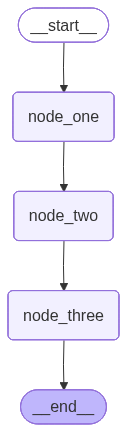

In [6]:
graph

# print(graph.get_graph().draw_ascii())